In [1]:
import numpy as np
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')
# Using this magic command, we turn on auto-reloading for libraries imported by %aimport
import Sub, Master
%load_ext autoreload
%autoreload 2
%aimport Sub
%aimport Master
%aimport FullInfo
%aimport DataPreparation

Set parameter Username
Set parameter LicenseID to value 2625858
Academic license - for non-commercial use only - expires 2026-02-20
Set parameter Username
Set parameter LicenseID to value 2625858
Academic license - for non-commercial use only - expires 2026-02-20
Set parameter Username
Set parameter LicenseID to value 2625858
Academic license - for non-commercial use only - expires 2026-02-20


# Functions

### Prepare Data

In [2]:
from DataPreparation import getMGData, buildCEMSData
def prepare_data(N):
    N_range = range(N)
    # Get data
    data_private, data_public = map(list, zip(*[getMGData(n) for n in N_range]))
    data_cems = buildCEMSData(data_public)
    # Calculate alpha
    sv = np.array([mg_n['sv'] for mg_n in data_private])
    sv_sum_exp = np.exp(sv).sum()
    alpha = np.exp(sv) / sv_sum_exp
    for n in range(N):
        data_private[n]['alpha'] = alpha[n]
    return data_private, data_cems

### Full Information Model

In [3]:
from FullInfo import *
def solve_full_model(N, T, data_private):
    jiant = Model(N=N, T=T, mg_data=data_private)
    # Solve central
    jiant.model.optimize()
    if jiant.model.SolCount > 0:
        print('Full information model solved successfuly.')
        result = jiant.get_var_values()
        with open(f'Solution/(N={N},T={T})FullInfo-solu.pkl', 'wb') as f:
            pkl.dump(result, f)
    else:
        raise ValueError(f'Optimization failed with model status {jiant.model.Status}.')

In [ ]:
# System (N: number of microgrids, T: trading horizon (hours))
N, T = 3, 24
# Get data
data_private, data_cems = prepare_data(N=N)
alphas = [data['alpha'] for data in data_private]
# Full info form: solve
solve_full_model(N, T, data_private)

Full information model solved successfuly.


# Lp Box ADMM Algorithm

In [5]:
# Sphere manifold class
class Manifold:
    def __init__(self, n_z):
        # Center of manifold
        self.c = 0.5 * np.ones(n_z)
        # Radius of the manifold
        self.r = np.sqrt(n_z) / 2

    def proj_to_tangent(self, z, vec):
        # Radial vector
        radial = z - self.c
        # Scalar value (z-c).T G / r^2
        scalar = (radial @ vec) / self.r**2
        # Removing the radial component of the gradient
        vec_tangent = vec - scalar * radial
        return vec_tangent
    
    def retract(self, z):
        radial = z - self.c
        radial_norm = np.linalg.norm(radial)
        return self.r * (radial / radial_norm) + self.c
# Penalty updater class
class PUpdater:
    def __init__(self, mu, tau, p_min=1e-3, p_max=1e3):
        self.mu = mu
        self.tau = tau
        self.p_min = p_min
        self.p_max = p_max

    def update(self, p, res_p, res_d):
        if res_p > self.mu * res_d:
            p *= self.tau
        elif res_d > self.mu * res_p:
            p /= self.tau
        return np.clip(p, self.p_min, self.p_max)
# Average of array/matrix l1 norm      
def avg_l1_norm(x):
    return np.sum(np.abs(x))/x.size

In [6]:
from Sub import Sub
from Master import Master
# Distributed form subproblems (subs) and master problem (central clearning problem)
subs = [Sub(T=T, N=N, data=data_private[n]) for n in range(N)]
master = Master(T=T, N=N, data=data_cems)
# Initializations
'''
y_shape:    the shape of all e_buy, e_sell, pi_buy, pi_sell variables stacked in the exact order.
            N, N, T refers to from MG i to j at time t.
            (0, 0, 1, 1): power bought by MG 0 from MG 1 at time 1.
            (2, 0, 1, 1): payment for power bought by MG 0 from MG 1 at time 1.
x_shape:    the shape of all original_binary variables associated with buy/sell mode.
'''
from copy import copy
y_shape = (4, N, N, T)
x_shape = (N, T)
y = np.empty(y_shape)               # Variable y 
x = np.empty(x_shape)               # Variable x

yhat = np.ones(y_shape)             # Auxiliary variables value for y (all \hat variables)
l_y = np.zeros(y_shape)             # Dual multipliers value for yhat=y

z1 = np.zeros(x_shape)              # Auxiliary variables value for x in box
z2 = np.zeros(x_shape)              # Auxiliary variables value for x on manifold
l_z1 = np.zeros(x_shape)            # Dual multipliers value for z1=x
l_z2 = np.zeros(x_shape)            # Dual multipliers value for z2=x

yhat_old = copy(yhat)                       # Copy of yhats
z1_old, z2_old = copy(z1), copy(z2)         # Copy of z1 and z2
l_y_old = copy(l_y)                         # Copy of l_y
l_z1_old, l_z2_old = copy(l_z1), copy(l_z1) # Copy of l_z1 and l_z2

p_y, p_z1, p_z2 = 1, 1, 1         # Penalty parameters
eps_y, eps_z = 0.1, 1e-2            # Termination criteria for y and z parts of Lagrnagian 
mu, tau = 10, 2                     # Parameters to control updates of penalties
M = Manifold(T)                     # Manifold class for projection and retraction
p_updater = PUpdater(mu=mu, tau=tau)
# Trajectories
traj_r_p = []
traj_r_d = []
traj_l_delta = []
# Algorithm
from time import time
itr = 0
max_itr = 500
start = time()
for itr in tqdm(range(max_itr)):
    # Solve MG subproblems
    for n, sub in enumerate(subs):
        # Input
        yhat_input = yhat_old[:,n, :, :]
        l_y_input = l_y[:, n, :, :]
        z1_input = z1_old[n]
        l_z1_input = l_z1_old[n]
        z2_input = z2_old[n]
        l_z2_input = l_z2_old[n]
        # Solve
        y_opt, x_opt = sub.solve_with(
            yhat = yhat_input,
            l_y = l_y_input,
            p_y = p_y,
            z1 = z1_input,
            l_z1 = l_z1_input,
            p_z1 = p_z1,
            z2 = z2_input,
            l_z2 = l_z2_input,
            p_z2 = p_z2,
            )
        # Store solutions
        y[:, n, :, :] = y_opt
        x[n] = x_opt
    
    # Solve master problem (market clearance)
    yhat = master.solve_with(y=y, p_y=p_y, l_y=l_y)

    # Update z1 by projection to [0,1] box
    z1 = np.clip(x + l_z1/p_z1, 0, 1)

    # Update z2 by projection on manifold
    z2 = M.retract(x + l_z2/p_z2)

    # Gradient ascent for dual multipliers
    l_y += p_y * (y - yhat)
    l_z1 += p_z1 * (x - z1)
    l_z2 += p_z2 * (x - z2)

    # Residuals primal: r_p and dual: r_d (average l1 norm)
    r_p = [avg_l1_norm(y - yhat),
           avg_l1_norm(x - z1), 
           avg_l1_norm(x - z2)]
    r_d = [p_y * avg_l1_norm(yhat - yhat_old), 
           p_z1 * avg_l1_norm(z1 - z1_old), 
           p_z2 * avg_l1_norm(z2 - z2_old)]
    r_y = r_p[0] + r_d[0]
    r_z = (r_p[1] + r_d[1]) + (r_p[2] + r_d[2])

    # Trajectories
    traj_r_p.append(r_p)
    traj_r_d.append(r_d)
    l_delta = [avg_l1_norm(l_y - l_y_old),
               avg_l1_norm(l_z1 - l_z1_old),
               avg_l1_norm(l_z2 - l_z2_old)]
    traj_l_delta.append(l_delta)

    # Update itr
    itr += 1
    yhat_old, z1_old, z2_old = copy(yhat), copy(z1), copy(z2) 
    l_y_old, l_z1_old, l_z2_old = copy(l_y), copy(l_z1), copy(l_z2)

    # Update penalty parameters
    p_y = p_updater.update(p_y, r_p[0], r_d[0])
    p_z1 = p_updater.update(p_z1, r_p[1], r_d[1])
    p_z2 = p_updater.update(p_z2, r_p[2], r_d[2])

    # Terminate
    done = all((r_y <= eps_y, r_z <= eps_z)) or itr >= max_itr
    if done:
        print(f'Terminated with total residual {sum(r_p) + sum(r_d):0.4f} in {itr} iterations.')
        break

 16%|█▌        | 81/500 [00:13<01:07,  6.18it/s]

Terminated with total residual 0.0099 in 82 iterations.


In [7]:
# Store solutions
for n, sub in enumerate(subs):
    sub.store_solutions(N=N, T=T, n=n)

# Numerical Analysis

### Plotting Algorithm Performance
The algorithm is considered converged when primal $r^p$ and dual $r^d$ residuals are meeting a predefined threshold.
$$r^p = \frac{|[y - \hat{y}; x-z_1; x-z_2]|}{n_y+2n_x} $$
$$r^d = \frac{|[\rho_y (\hat{y}^{k+1} - \hat{y}^k); \rho_{z_1}(z_1^{k+1}-z_1^{k}); \rho_{z_2}(z_2^{k+1}-z_2^{k})]|}{n_y+2n_x} $$
Terminate if
$$r^p + r^d \leq \epsilon$$


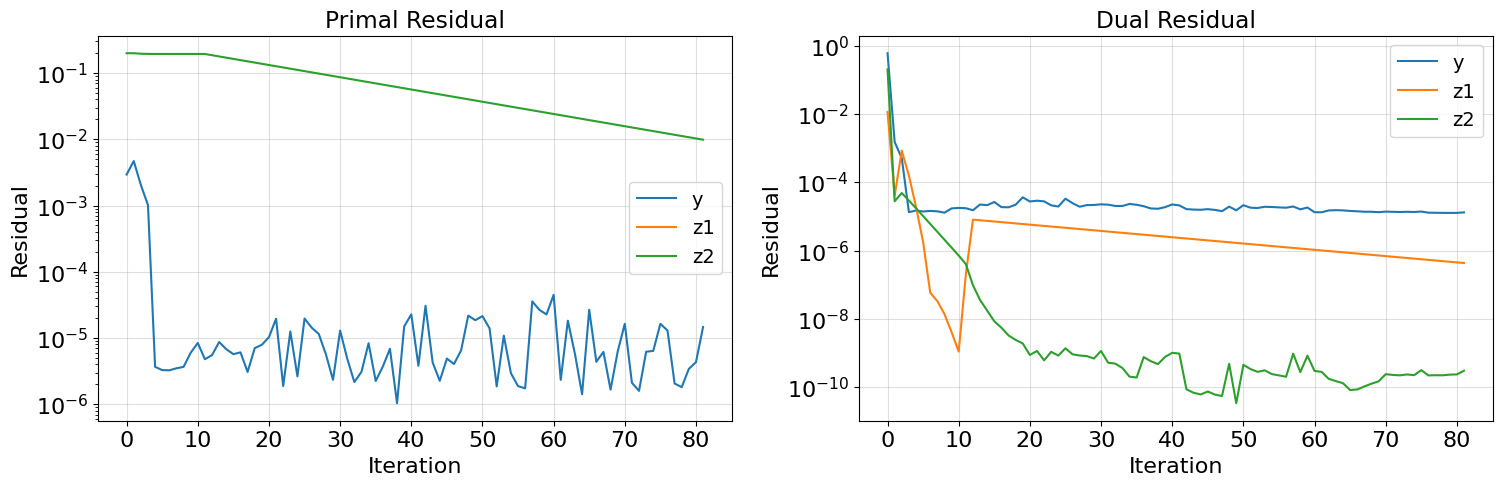

In [ ]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 2, figsize=(18, 5))
plt.rcParams['font.size'] = 14
plt.subplots_adjust(hspace=0.6)

axs[0].semilogy(traj_r_p, label=['y', 'z1', 'z2'])
axs[0].set_title('Primal Residual')

axs[1].semilogy(traj_r_d, label=['y', 'z1', 'z2'])
axs[1].set_title('Dual Residual')

for ax in axs:
    ax.legend()
    ax.set_xlabel('Iteration')
    ax.set_ylabel('Residual')
    ax.grid(alpha=0.4)

plt.savefig(f'Figures/(N={N},T={T})residuals.jpg', dpi=600, bbox_inches='tight')

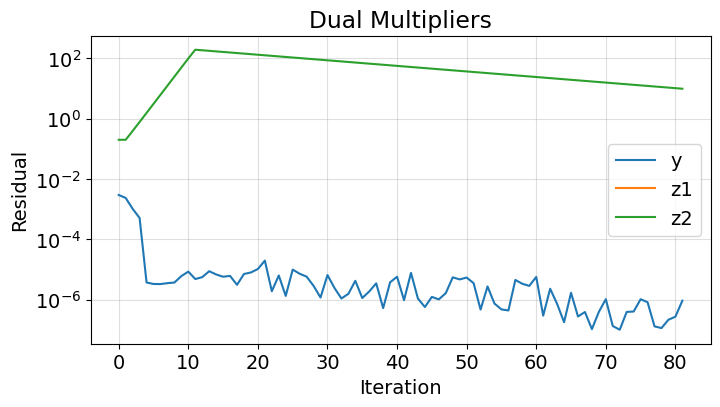

In [ ]:
plt.figure(figsize=(8, 4))
plt.semilogy(traj_l_delta, label=['y', 'z1', 'z2'])
plt.title('Dual Multipliers')
plt.xlabel('Iteration')
plt.ylabel('Residual')
plt.grid(alpha=0.4)
plt.legend()
plt.savefig(f'Figures/(N={N},T={T})dual-multipliers.jpg', dpi=600, bbox_inches='tight')

### Comparing With Central Mode

### Trading Solutions

In [ ]:
from Results import *
results = {n: MGResults(N=N, T=T, n=n, data_private=data_private[n]) for n in range(N)}

# Cost table
get_cost_table(results, N, T)

# Resilience and cost reduction
get_metric_table(results, N, T, alphas)

# KPI
get_kpi_table(results, N, T)

# Power table
get_power_table(results, N, T, alphas)

# Load satisfaction plot
plot_load_served(results, N, T)

# Plot trade
plot_trade(results, N, T)

# Plot demand satisfaction
plot_demand(results, N, T)

### Comparing With Central Mode

In [63]:
from Results import *
compare_with_fullinfo(results, N, T)